In [14]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data import load_simple_price_csv
from src.core import Asset, Capital, FixedContractsSizer, FixedCapitalModel
from src.strategies import BuyAndHoldStrategy
from src.engine import VectorizedEngine, PerformanceAnalyzer, BacktestRunner
from src.visualization import print_summary, plot_backtest_results

In [16]:
# 1. Prepare data
data = load_simple_price_csv("../data/MCFTR.csv")
display(data.head())

0
2003-02-26    335.67
2003-02-27    338.35
2003-02-28    341.52
2003-03-03    352.24
2003-03-04    348.40
Name: UNKNOWN, dtype: float64

In [17]:
# 2. The most verbose declarations version, for shorter options look below
MCFTR = Asset(ticker= 'MCFTR', price_data=data, commission_rate=0.0004, slippage_rate=0.001)
capital = Capital(initial_capital=100_000, risk_free_rate=0.0, capital_model=FixedCapitalModel())
position_sizer = FixedContractsSizer(max_allocation=0.01)

In [18]:
strategy = BuyAndHoldStrategy()

In [19]:
engine = VectorizedEngine(capital, position_sizer)

In [20]:
# 3. Running the backtest
exec_result = engine.run(strategy, asset=MCFTR)

In [21]:
# 4. Analyzing the results
analyzer = PerformanceAnalyzer(capital)
perf_metrics = analyzer.analyze(exec_result)

In [22]:
print_summary(name="BuyAndHoldStrategy", metrics=perf_metrics)


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: BuyAndHoldStrategy
════════════════════════════════════════════════════════════
 Total Return:         14.27%
 CAGR:                  0.63%
 Annual Volatility:     1.83%
 Sharpe Ratio:          0.34
 Sortino Ratio:        33.88
------------------------------------------------------------
 Max Drawdown:         -8.70%
 Avg Drawdown:         -0.26%
 Win Rate:             53.69%
------------------------------------------------------------
 Skew:                 -7.06
 Kurtosis:            256.73
 Tail Risk:             2.69
------------------------------------------------------------
 Gross PnL:         $ 14,269.04
 Net PnL:           $ 14,268.09
 Total Fees:        $      0.95
 Fee Drag Ratio:        0.00
 Cost Efficiency:       1.00
════════════════════════════════════════════════════════════



c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


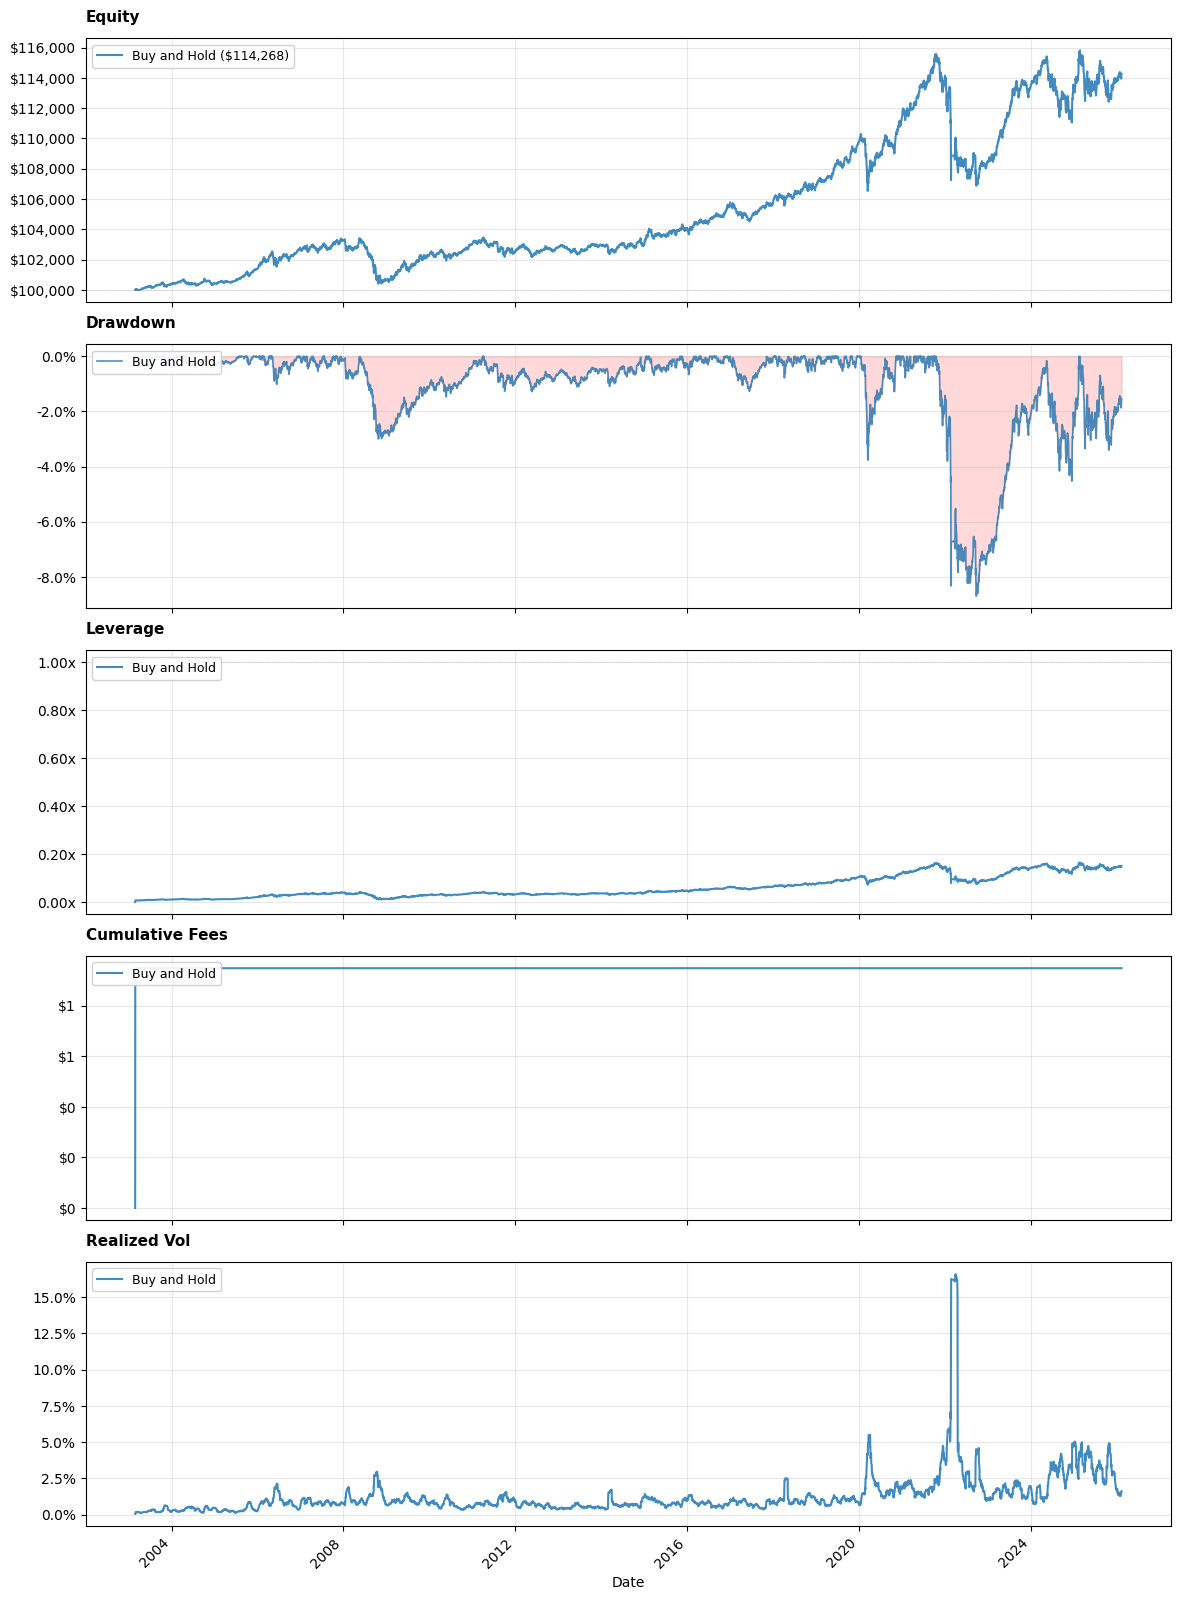

In [23]:
plot_backtest_results(exec_result, panels=['equity', 'drawdown', 'leverage', 'cumulative_fees', 'realized_vol'])


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: BuyAndHoldStrategy
════════════════════════════════════════════════════════════
 Total Return:         14.27%
 CAGR:                  0.63%
 Annual Volatility:     1.83%
 Sharpe Ratio:          0.34
 Sortino Ratio:        33.88
------------------------------------------------------------
 Max Drawdown:         -8.70%
 Avg Drawdown:         -0.26%
 Win Rate:             53.69%
------------------------------------------------------------
 Skew:                 -7.06
 Kurtosis:            256.73
 Tail Risk:             2.69
------------------------------------------------------------
 Gross PnL:         $ 14,269.04
 Net PnL:           $ 14,268.09
 Total Fees:        $      0.95
 Fee Drag Ratio:        0.00
 Cost Efficiency:       1.00
════════════════════════════════════════════════════════════



c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


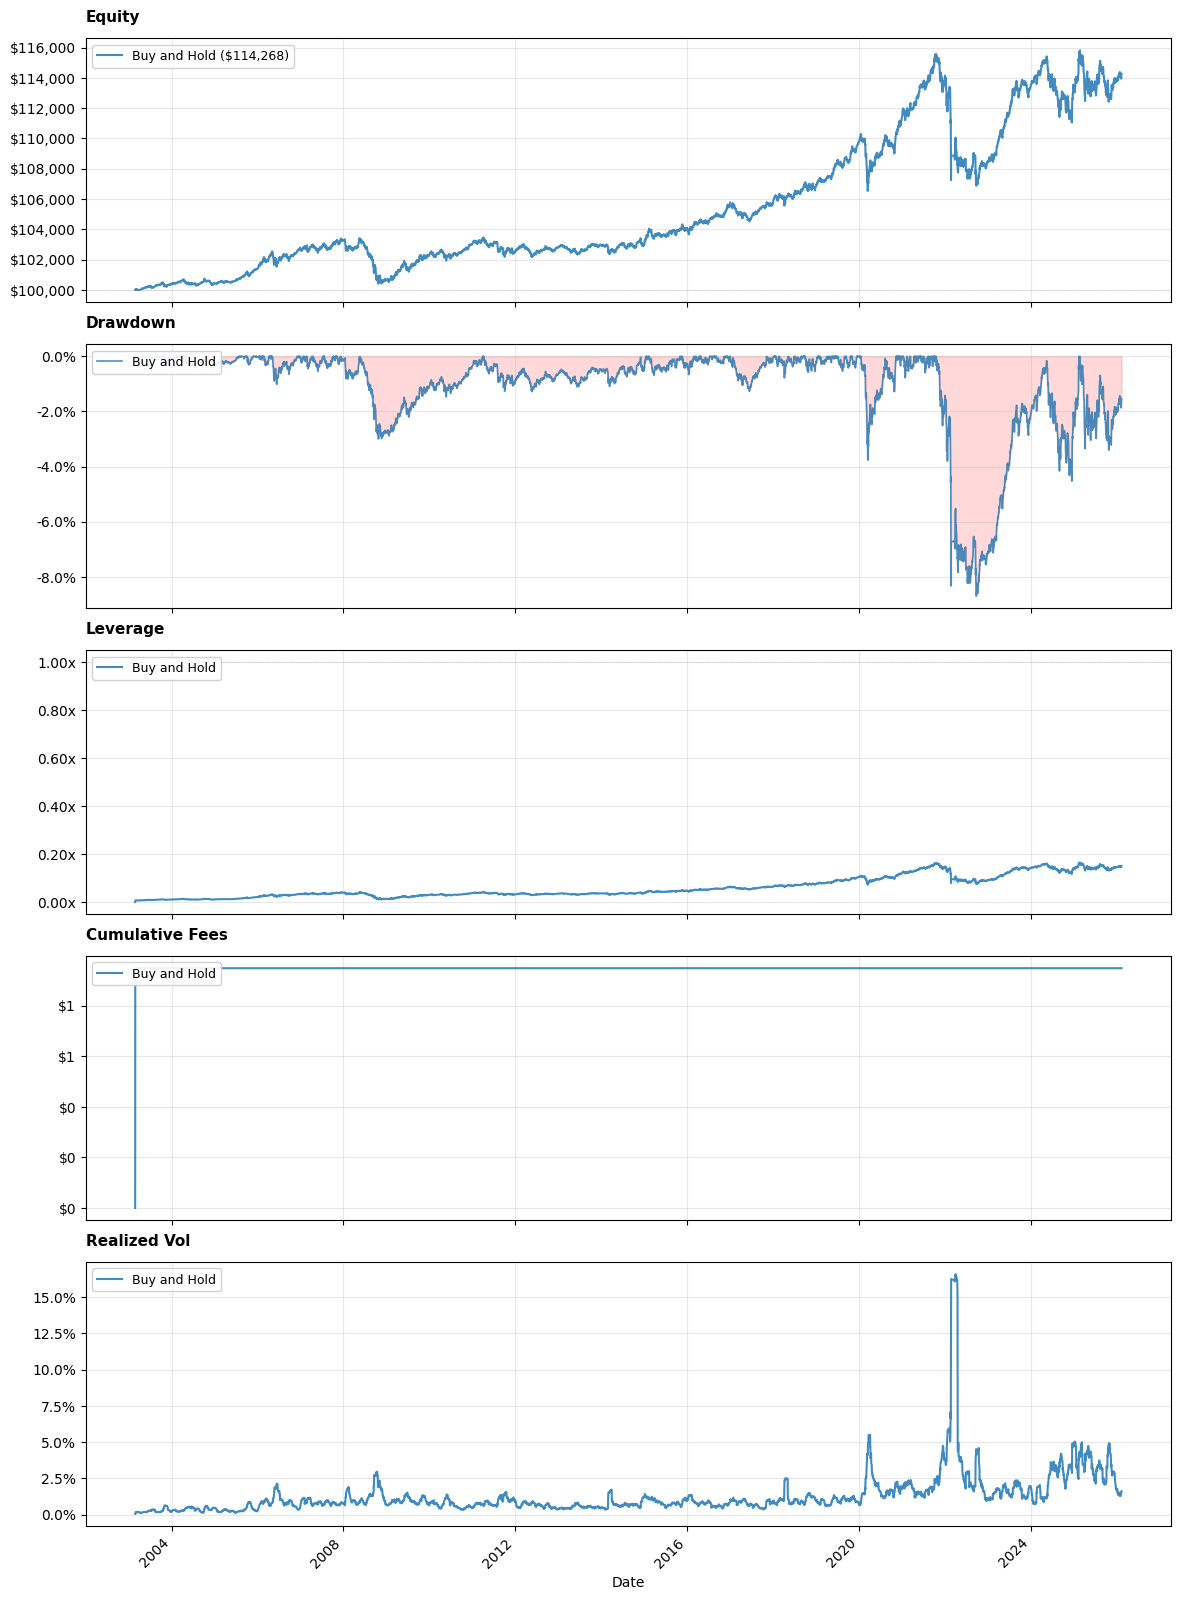

In [24]:
## The same code but less verbose using default values
MCFTR = Asset(ticker= 'MCFTR', price_data=data, commission_rate=0.0004, slippage_rate=0.001)
engine = VectorizedEngine(Capital(), FixedContractsSizer(max_allocation=0.01))
exec_result = engine.run(BuyAndHoldStrategy(), asset=MCFTR)
perf_metrics = PerformanceAnalyzer(Capital()).analyze(exec_result)
print_summary(name="BuyAndHoldStrategy", metrics=perf_metrics)
plot_backtest_results(exec_result)


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: Buy and Hold
════════════════════════════════════════════════════════════
 Total Return:         14.27%
 CAGR:                  0.63%
 Annual Volatility:     1.83%
 Sharpe Ratio:          0.34
 Sortino Ratio:        33.88
------------------------------------------------------------
 Max Drawdown:         -8.70%
 Avg Drawdown:         -0.26%
 Win Rate:             53.69%
------------------------------------------------------------
 Skew:                 -7.06
 Kurtosis:            256.73
 Tail Risk:             2.69
------------------------------------------------------------
 Gross PnL:         $ 14,269.04
 Net PnL:           $ 14,268.09
 Total Fees:        $      0.95
 Fee Drag Ratio:        0.00
 Cost Efficiency:       1.00
════════════════════════════════════════════════════════════



c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


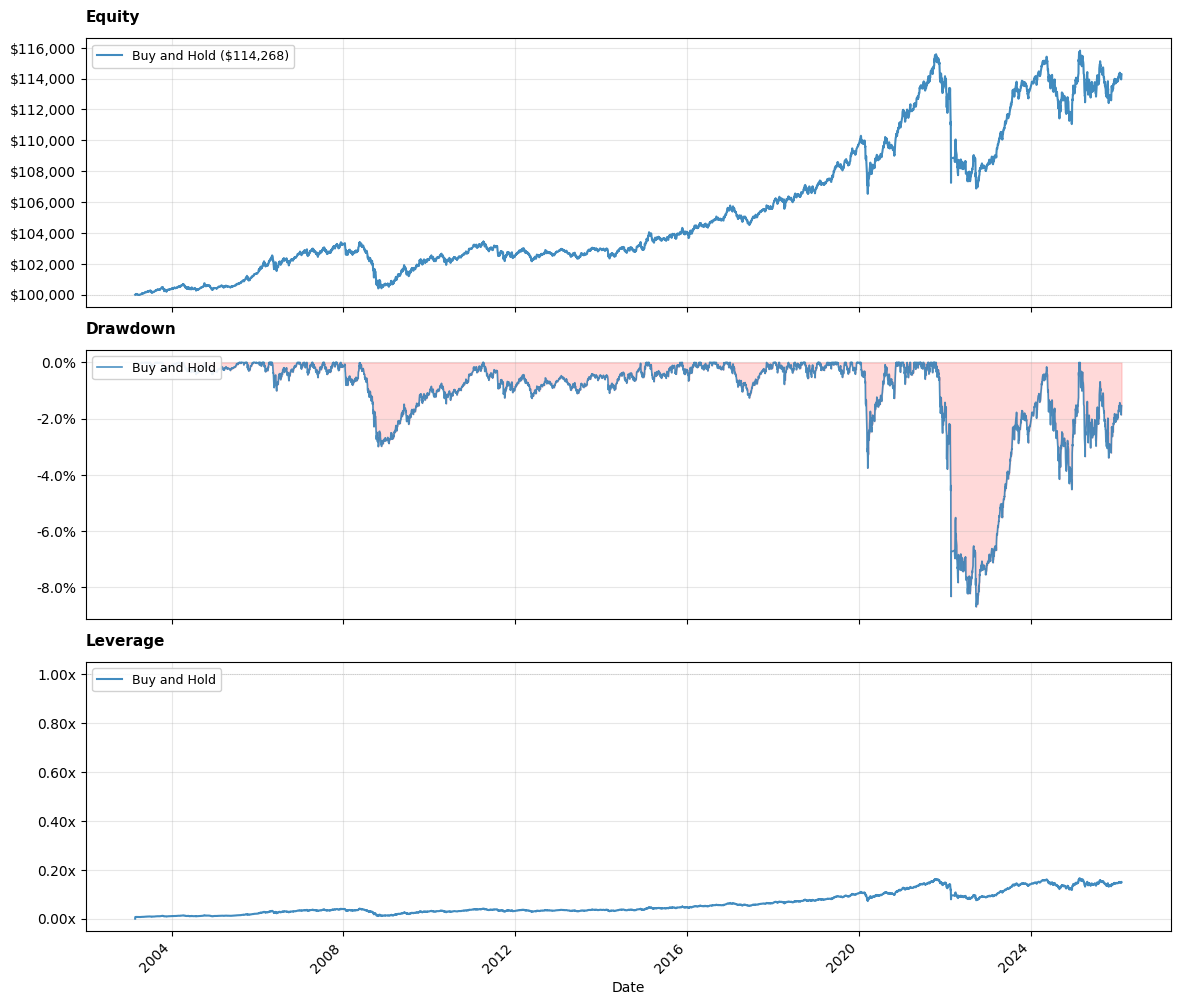

In [25]:
### The same code again utilizing convenience wrapper
MCFTR = Asset(ticker= 'MCFTR', price_data=data, commission_rate=0.0004, slippage_rate=0.001)
backtester = BacktestRunner(capital=Capital(), asset=MCFTR, sizer=FixedContractsSizer(max_allocation=0.01))
report = backtester.run(strategy=BuyAndHoldStrategy())
report.print_summary()
report.plot()

🔬 Testing Buy & Hold position size sensitivity...
  0.01 → Return:  14.27%, Sharpe: 0.34, Max DD: -8.7%
  0.03 → Return:  57.07%, Sharpe: 0.34, Max DD: -34.8%
  0.05 → Return:  99.88%, Sharpe: 0.34, Max DD: -60.9%
  0.1 → Return: 206.89%, Sharpe: 0.34, Max DD: -100.0%
  0.15 → Return: 313.90%, Sharpe: 0.34, Max DD: -100.0%
  0.25 → Return: 527.92%, Sharpe: 0.34, Max DD: -100.0%
  0.4 → Return: 848.95%, Sharpe: 0.34, Max DD: -100.0%
  0.5 → Return: 1055.84%, Sharpe: 0.34, Max DD: -100.0%
  0.7 → Return: 1483.88%, Sharpe: 0.34, Max DD: -100.0%
  1 → Return: 2118.81%, Sharpe: 0.34, Max DD: -100.0%


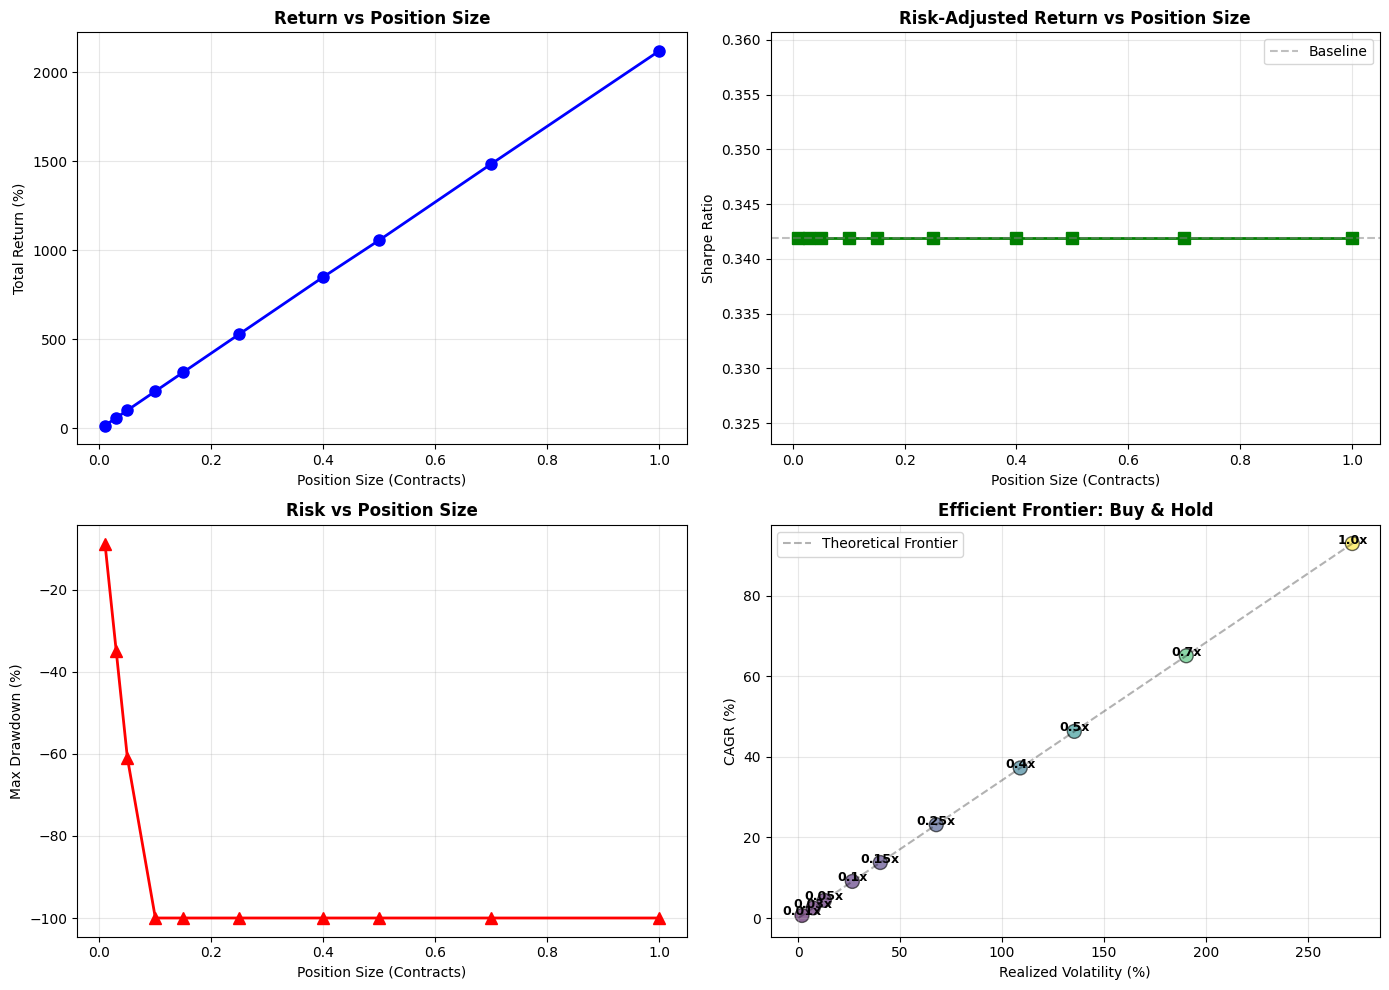

,Position Size (contracts),Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%),Volatility (%)
0,0.01,14.27,0.63,0.34,-8.7,1.83
1,0.03,57.07,2.50,0.34,-34.8,7.32
2,0.05,99.88,4.38,0.34,-60.9,12.82
3,0.10,206.89,9.08,0.34,-100.0,26.55
4,0.15,313.90,13.77,0.34,-100.0,40.28
5,0.25,527.92,23.16,0.34,-100.0,67.75
6,0.40,848.95,37.25,0.34,-100.0,108.94
7,0.50,1055.84,46.32,0.34,-100.0,135.49
8,0.70,1483.88,65.10,0.34,-100.0,190.42
9,1.00,2118.81,92.96,0.34,-100.0,271.90


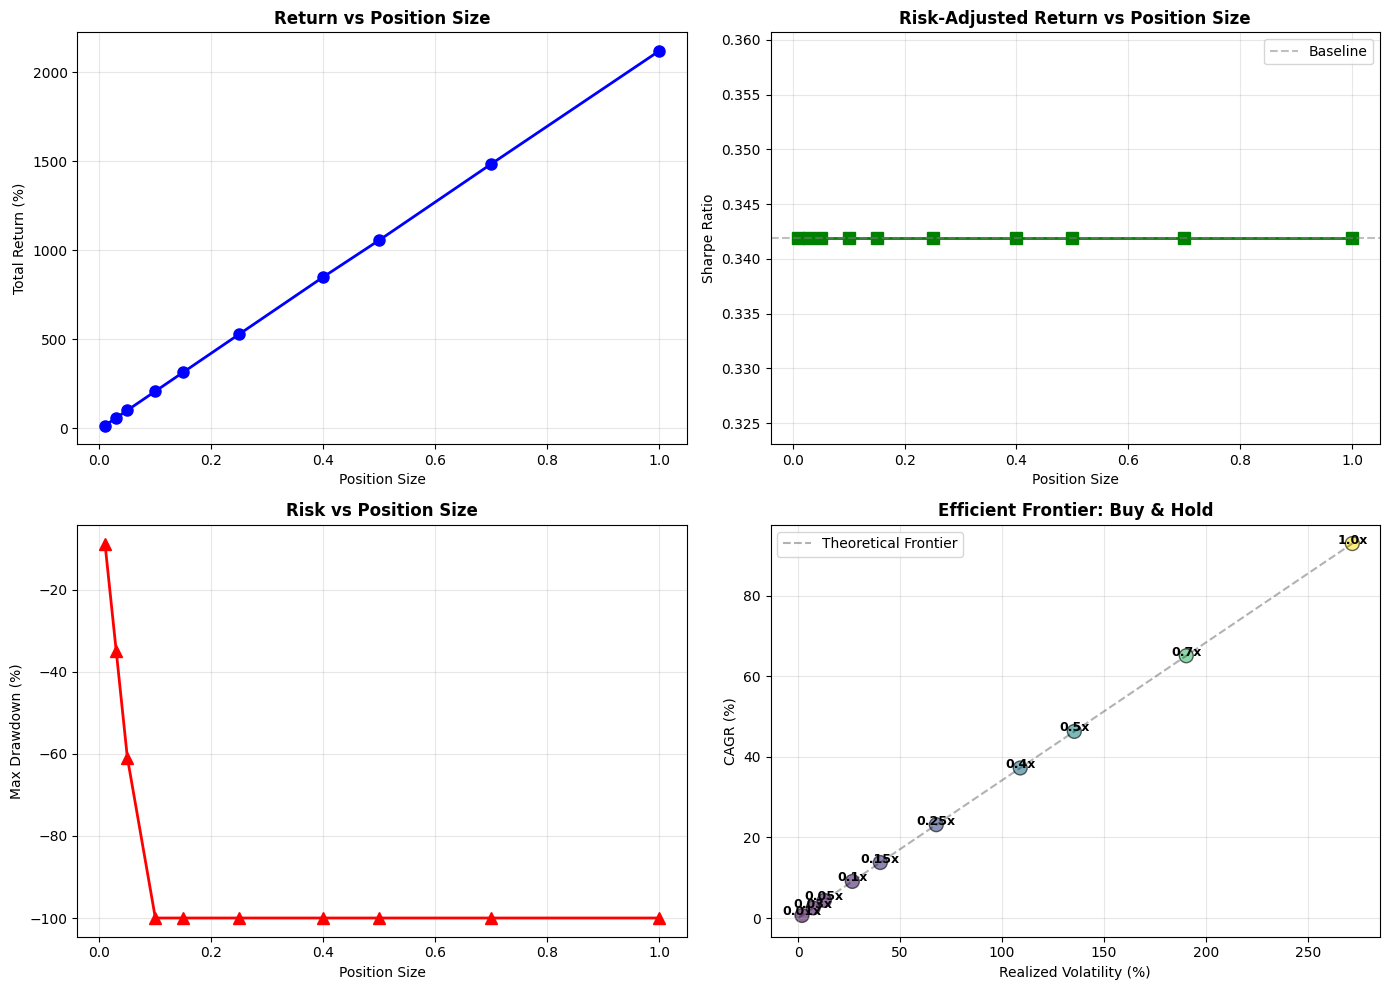

,Position Size,Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%),Volatility (%)
0,0.01,14.27,0.63,0.34,-8.7,1.83
1,0.03,57.07,2.50,0.34,-34.8,7.32
2,0.05,99.88,4.38,0.34,-60.9,12.82
3,0.10,206.89,9.08,0.34,-100.0,26.55
4,0.15,313.90,13.77,0.34,-100.0,40.28
5,0.25,527.92,23.16,0.34,-100.0,67.75
6,0.40,848.95,37.25,0.34,-100.0,108.94
7,0.50,1055.84,46.32,0.34,-100.0,135.49
8,0.70,1483.88,65.10,0.34,-100.0,190.42
9,1.00,2118.81,92.96,0.34,-100.0,271.90


In [28]:
# %% [markdown]
# ## Buy & Hold: Position Size Sensitivity Analysis
# 
# Test how different position sizes (number of contracts) affect performance.
# This isolates the impact of leverage on returns, risk, and risk-adjusted metrics.
# %%
# Configuration
POSITION_SIZES = [0.01, 0.03, 0.05, 0.1, 0.15, 0.25, 0.4, 0.5, 0.7, 1]  

print("🔬 Testing Buy & Hold position size sensitivity...")
results_position = []

for pos in POSITION_SIZES:
    # BacktestRunner returns a BacktestReport object
    backtester = BacktestRunner(capital=Capital(), asset=MCFTR, sizer=FixedContractsSizer(max_allocation=pos))
    report = backtester.run(strategy=BuyAndHoldStrategy())
    results_position.append(report)
    
    # ✅ FIX: Use dot notation for dataclass attributes
    print(f"  {pos} → Return: {report.metrics.total_return_pct:6.2f}%, "
          f"Sharpe: {report.metrics.sharpe_ratio:.2f}, "
          f"Max DD: {report.metrics.max_drawdown_pct:.1f}%")
# %% [markdown]
# ### Position Size Sensitivity: Visual Analysis

# %%
# Extract metrics into DataFrame
# ✅ FIX: Changed column name to 'Position Size (contracts)' to match the plotting code below
position_metrics = pd.DataFrame({
    'Position Size (contracts)': POSITION_SIZES,
    'Total Return (%)': [r.metrics.total_return_pct for r in results_position],
    'CAGR (%)': [r.metrics.cagr_pct for r in results_position],
    'Sharpe Ratio': [r.metrics.sharpe_ratio for r in results_position],
    'Max Drawdown (%)': [r.metrics.max_drawdown_pct for r in results_position],
    'Volatility (%)': [r.metrics.annual_volatility_pct for r in results_position],
})

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Total Return vs Position Size
axes[0, 0].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Total Return (%)'], 
                marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Position Size (Contracts)')
axes[0, 0].set_ylabel('Total Return (%)')
axes[0, 0].set_title('Return vs Position Size', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Sharpe Ratio vs Position Size
axes[0, 1].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Sharpe Ratio'], 
                marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].axhline(position_metrics['Sharpe Ratio'].iloc[0], 
                   color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Position Size (Contracts)')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Risk-Adjusted Return vs Position Size', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Max Drawdown vs Position Size
axes[1, 0].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Max Drawdown (%)'], 
                marker='^', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Position Size (Contracts)')
axes[1, 0].set_ylabel('Max Drawdown (%)')
axes[1, 0].set_title('Risk vs Position Size', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Efficient Frontier (Volatility vs CAGR)
axes[1, 1].scatter(position_metrics['Volatility (%)'], 
                   position_metrics['CAGR (%)'], 
                   s=100, c=position_metrics['Position Size (contracts)'], 
                   cmap='viridis', alpha=0.6, edgecolors='black')

for _, row in position_metrics.iterrows():
    axes[1, 1].annotate(f"{row['Position Size (contracts)']}x", 
                       (row['Volatility (%)'], row['CAGR (%)']),
                       fontsize=9, ha='center', fontweight='bold')

if len(position_metrics) >= 2:
    slope = position_metrics['CAGR (%)'].iloc[-1] / position_metrics['Volatility (%)'].iloc[-1]
    x_line = np.linspace(0, position_metrics['Volatility (%)'].max(), 100)
    axes[1, 1].plot(x_line, slope * x_line, 'k--', alpha=0.3, label='Theoretical Frontier')

axes[1, 1].set_xlabel('Realized Volatility (%)')
axes[1, 1].set_ylabel('CAGR (%)')
axes[1, 1].set_title('Efficient Frontier: Buy & Hold', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(position_metrics.round(2))

# %% [markdown]
# ### Key Insights: Buy & Hold Position Sizing

# %%
# %%
# Extract metrics into DataFrame
# ✅ FIX: Changed column name to 'Position Size (contracts)' to match the plotting code below
position_metrics = pd.DataFrame({
    'Position Size': POSITION_SIZES,
    'Total Return (%)': [r.metrics.total_return_pct for r in results_position],
    'CAGR (%)': [r.metrics.cagr_pct for r in results_position],
    'Sharpe Ratio': [r.metrics.sharpe_ratio for r in results_position],
    'Max Drawdown (%)': [r.metrics.max_drawdown_pct for r in results_position],
    'Volatility (%)': [r.metrics.annual_volatility_pct for r in results_position],
})

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Total Return vs Position Size
axes[0, 0].plot(position_metrics['Position Size'], 
                position_metrics['Total Return (%)'], 
                marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Position Size')
axes[0, 0].set_ylabel('Total Return (%)')
axes[0, 0].set_title('Return vs Position Size', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Sharpe Ratio vs Position Size
axes[0, 1].plot(position_metrics['Position Size'], 
                position_metrics['Sharpe Ratio'], 
                marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].axhline(position_metrics['Sharpe Ratio'].iloc[0], 
                   color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Position Size')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Risk-Adjusted Return vs Position Size', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Max Drawdown vs Position Size
axes[1, 0].plot(position_metrics['Position Size'], 
                position_metrics['Max Drawdown (%)'], 
                marker='^', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Position Size')
axes[1, 0].set_ylabel('Max Drawdown (%)')
axes[1, 0].set_title('Risk vs Position Size', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Efficient Frontier (Volatility vs CAGR)
axes[1, 1].scatter(position_metrics['Volatility (%)'], 
                   position_metrics['CAGR (%)'], 
                   s=100, c=position_metrics['Position Size'], 
                   cmap='viridis', alpha=0.6, edgecolors='black')

for _, row in position_metrics.iterrows():
    axes[1, 1].annotate(f"{row['Position Size']}x", 
                       (row['Volatility (%)'], row['CAGR (%)']),
                       fontsize=9, ha='center', fontweight='bold')

if len(position_metrics) >= 2:
    slope = position_metrics['CAGR (%)'].iloc[-1] / position_metrics['Volatility (%)'].iloc[-1]
    x_line = np.linspace(0, position_metrics['Volatility (%)'].max(), 100)
    axes[1, 1].plot(x_line, slope * x_line, 'k--', alpha=0.3, label='Theoretical Frontier')

axes[1, 1].set_xlabel('Realized Volatility (%)')
axes[1, 1].set_ylabel('CAGR (%)')
axes[1, 1].set_title('Efficient Frontier: Buy & Hold', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(position_metrics.round(2))